In [199]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [120]:
# sim = "m12i"
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]

sim_dir = "/Users/z5114326/Documents/simulations/"
sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

dat_dir = "../data/"
mw_gcs_fil = "mw_gcs/mw_gcs.csv"
mw_gcs = pd.read_csv(dat_dir + mw_gcs_fil)

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == 600]["time_Gyr"].values[0])

In [194]:
def safe_interpolate(x, y, mass_grid):
    interp_func = interp1d(x, y, kind="linear", bounds_error=False, fill_value=(0, 1))
    return interp_func(mass_grid)


def get_cdf(arr):
    return np.cumsum(arr) / np.sum(arr)

In [202]:
mass_grid = np.logspace(1, 8, 1000)
feh_grid = np.linspace(-4, 0.5, 1000)
r_grid = np.logspace(-1, 3, 1000)
age_grid = np.linspace(0, 14, 1000)

mass_dict = {sim: {"avg": None, "std": None} for sim in sim_lst}
feh_dict = {sim: {"avg": None, "std": None} for sim in sim_lst}
r_dict = {sim: {"avg": None, "std": None} for sim in sim_lst}
age_dict = {sim: {"avg": None, "std": None} for sim in sim_lst}

for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    mass_cdf = []
    feh_cdf = []
    r_cdf = []
    age_cdf = []
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        smsk = src_dat["s_flag"][()].astype(bool)
        log_mass = src_dat["logm_tz0"][smsk]
        mass = 10**log_mass

        feh = src_dat["feh"][smsk]

        r = np.linalg.norm(src_dat["pxyz_snap600"][smsk], axis=1)

        age = timez0 - src_dat["tfor"][smsk]

        mass_sort = np.sort(mass)
        feh_sort = np.sort(feh)
        r_sort = np.sort(r)
        age_sort = np.sort(age)

        mass_cdf.append(safe_interpolate(mass_sort, get_cdf(mass_sort), mass_grid))
        feh_cdf.append(safe_interpolate(feh_sort, get_cdf(feh_sort), feh_grid))
        r_cdf.append(safe_interpolate(r_sort, get_cdf(r_sort), r_grid))
        age_cdf.append(safe_interpolate(age_sort, get_cdf(age_sort), age_grid))

    mass_cdf = np.array(mass_cdf)
    feh_cdf = np.array(feh_cdf)
    r_cdf = np.array(r_cdf)
    age_cdf = np.array(age_cdf)

    mass_dict[sim]["avg"] = np.mean(mass_cdf, axis=0)
    mass_dict[sim]["std"] = np.std(mass_cdf, axis=0)

    feh_dict[sim]["avg"] = np.mean(feh_cdf, axis=0)
    feh_dict[sim]["std"] = np.std(feh_cdf, axis=0)

    r_dict[sim]["avg"] = np.mean(r_cdf, axis=0)
    r_dict[sim]["std"] = np.std(r_cdf, axis=0)

    age_dict[sim]["avg"] = np.mean(age_cdf, axis=0)
    age_dict[sim]["std"] = np.std(age_cdf, axis=0)

In [210]:
mw_dict = {"mass": None, "feh": None, "r": None, "age": None}

mw_mass_sort = np.sort(np.asanyarray(mw_gcs["mass"]))
mw_mass_cdf = safe_interpolate(mw_mass_sort, get_cdf(mw_mass_sort), mass_grid)
# mw_mass_cdf = gaussian_filter1d(mw_mass_cdf, sigma=3)
mw_dict["mass"] = mw_mass_cdf

mw_feh_nans = np.isnan(mw_gcs["feh"])
mw_feh_sort = np.sort(np.asanyarray(mw_gcs["feh"][~mw_feh_nans]))
mw_feh_cdf = safe_interpolate(mw_feh_sort, get_cdf(mw_feh_sort), feh_grid)
# mw_feh_cdf = gaussian_filter1d(mw_feh_cdf, sigma=3)
mw_dict["feh"] = mw_feh_cdf

mw_r_sort = np.sort(np.asanyarray(mw_gcs["r_gc"]))
mw_r_cdf = safe_interpolate(mw_r_sort, get_cdf(mw_r_sort), r_grid)
# mw_r_cdf = gaussian_filter1d(mw_r_cdf, sigma=3)
mw_dict["r"] = mw_r_cdf

mw_age_nans = np.isnan(mw_gcs["age_gyr"])
mw_age_sort = np.sort(np.asanyarray(mw_gcs["age_gyr"][~mw_age_nans]))
mw_age_cdf = safe_interpolate(mw_age_sort, get_cdf(mw_age_sort), age_grid)
# mw_age_cdf = gaussian_filter1d(mw_age_cdf, sigma=3)
mw_dict["age"] = mw_age_cdf

Text(0, 0.5, 'P ( < Age )')

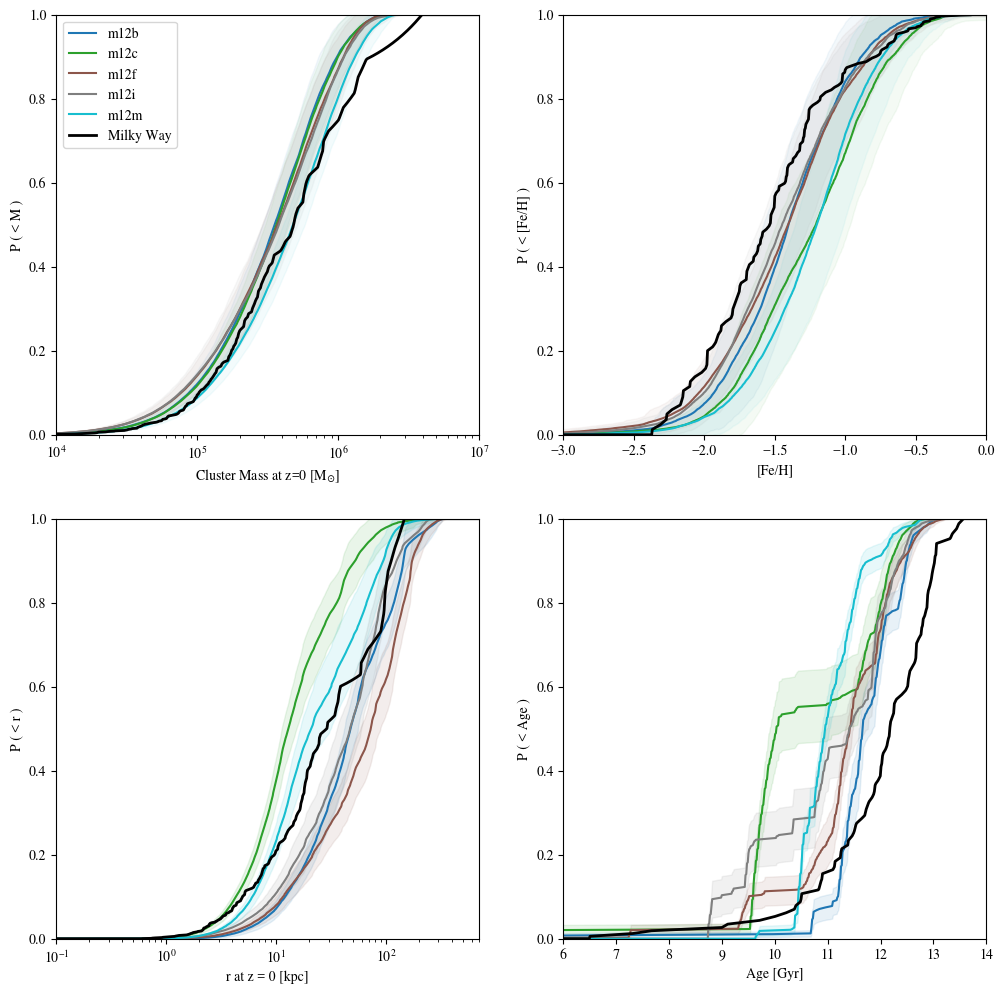

In [213]:
plt_error = True

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
plt.subplots_adjust()

for sim in mass_dict.keys():
    mcdf = mass_dict[sim]["avg"]
    axs[0, 0].plot(mass_grid, mcdf, c=sim_colors[sim], label=sim)

    fcdf = feh_dict[sim]["avg"]
    axs[0, 1].plot(feh_grid, fcdf, c=sim_colors[sim], label=sim)

    rcdf = r_dict[sim]["avg"]
    axs[1, 0].plot(r_grid, rcdf, c=sim_colors[sim], label=sim)

    acdf = age_dict[sim]["avg"]
    axs[1, 1].plot(age_grid, acdf, c=sim_colors[sim], label=sim)

    if plt_error:
        axs[0, 0].fill_between(
            mass_grid,
            mcdf - mass_dict[sim]["std"],
            mcdf + mass_dict[sim]["std"],
            color=sim_colors[sim],
            alpha=0.05,
        )

        axs[0, 1].fill_between(
            feh_grid,
            fcdf - feh_dict[sim]["std"],
            fcdf + feh_dict[sim]["std"],
            color=sim_colors[sim],
            alpha=0.05,
        )

        axs[1, 0].fill_between(
            r_grid,
            rcdf - r_dict[sim]["std"],
            rcdf + r_dict[sim]["std"],
            color=sim_colors[sim],
            alpha=0.1,
        )

        axs[1, 1].fill_between(
            age_grid,
            acdf - age_dict[sim]["std"],
            acdf + age_dict[sim]["std"],
            color=sim_colors[sim],
            alpha=0.1,
        )

# MW Lines ################################################

axs[0, 0].plot(mass_grid, mw_dict["mass"], c="k", lw=2, label="Milky Way")
axs[0, 1].plot(feh_grid, mw_dict["feh"], c="k", lw=2, label="Milky Way")
axs[1, 0].plot(r_grid, mw_dict["r"], c="k", lw=2, label="Milky Way")
axs[1, 1].plot(age_grid, mw_dict["age"], c="k", lw=2, label="Milky Way")

###########################################################


axs[0, 0].set_xscale("log")
axs[0, 0].set_xlim(10**4, 10**7)
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_xlabel(r"Cluster Mass at z=0 [M$_{\odot}$]")
axs[0, 0].set_ylabel("P ( < M )")
axs[0, 0].legend()

axs[0, 1].set_xlim(-3, 0)
axs[0, 1].set_ylim(0, 1)
axs[0, 1].set_xlabel(r"[Fe/H]")
axs[0, 1].set_ylabel("P ( < [Fe/H] )")

axs[1, 0].set_xscale("log")
axs[1, 0].set_xlim(10**-1, 7 * 10**2)
axs[1, 0].set_ylim(0, 1)
axs[1, 0].set_xlabel(r"r at z = 0 [kpc]")
axs[1, 0].set_ylabel("P ( < r )")

axs[1, 1].set_xlim(6, 14)
axs[1, 1].set_ylim(0, 1)
axs[1, 1].set_xlabel(r"Age [Gyr]")
axs[1, 1].set_ylabel("P ( < Age )")